In [15]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans


from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [16]:
# Load the data
df= pd.read_csv("insurance.csv")
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [17]:
df.shape

(1338, 7)

In [18]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [19]:
# No of categories in region
df['region'].nunique()

4

In [20]:
# unique categories in region
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [21]:
# Converts categorical columns to numerical in sex, region, smoker
df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

# Onehot encoding for region
df = pd.get_dummies(df, columns=['region'], drop_first=True)
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


In [22]:
# Remove NaN values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

# Reset the index
df = df.reset_index(drop=True)

In [23]:
len(df.columns)

9

REDUNDANCY MANAGEMENT WITH PCA .

AS PER THE SCREE PLOT.....................

PC1 explained 19% of the variance

PC2 explained 16% of the variance

PC3 explained 14% of the variance

PC4 explained 13% of the variance

So the first 4PCs are explained 62% variances in the total dataset

Each PC is linear combination of the original feature

AS ÖER THE CUMULATIVE EXPLAINED VARIANCEPLOT................

The first PC explained 19%, PC1+PC2 explained 19+16=35%, PC1+PC2+PC3 explained 50% , Finally PC1+PC2+PC3+PC4 explained 63% of the Data set

In [ ]:
# I did all input variables except the target Charges
# Y is Targeted variable which is Charges 
# Then PCA compresses the original features into 4 new variables (principal components)that capture the main patterns in the data.
# Checking how many PCA components are enough to represent dataset without losing too much information.
# here 4 components explain most of the variance with low MSE, its means safely reduce dataset’s dimensions from many features to just 4 key components also making analysis and modeling faster and simpler. 
# Then ploting the information mean Visulizations. lets let me show one by one with explanations and experiments.


In [ ]:
# Results
#Scree Plot shows how much information each of the four PCA components captures individually. The first component explains about 19.2% of the variance, the second about 16.6%, the third around 13.7%, and the fourth roughly 13.3%. The bars decrease slightly, showing that each additional component adds less new information. This pattern suggests that most of the important variation in the dataset is captured by the first few components. It helps identify the point where adding more components gives diminishing returns.

# Cumulative Explained Variance Plot displays how the total captured information increases as more components are added together. Starting from one component explaining 19.2%, the total grows to about 63% after including all four components. The smooth upward red dashed line shows consistent information gain with each addition. This means four components together preserve most of the dataset’s useful variance. The plot helps decide how many components are enough to represent the data effectively.

Explained variance ratio with 4 components, by each component:
[0.19216322 0.16583517 0.13704414 0.132862  ]

Total explained variance with 4 components:
0.6279045268364714

Mean Squared Error (MSE): 0.3720954731635286


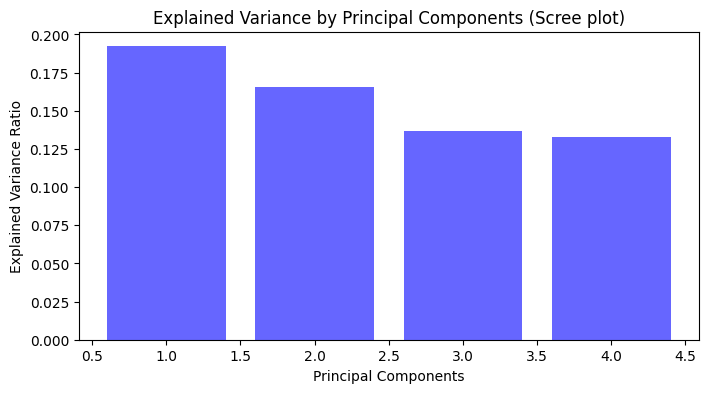

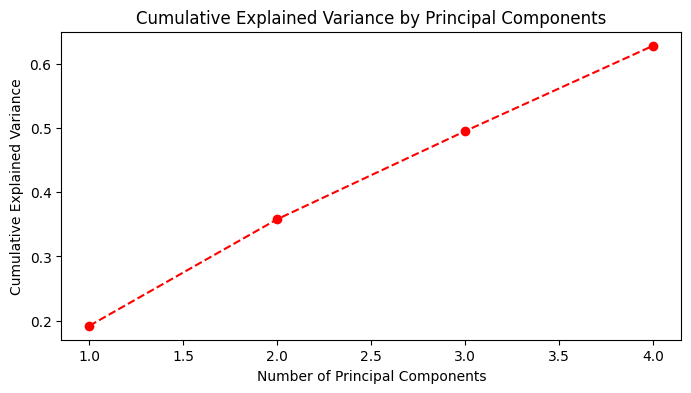

In [24]:
# X / y split
X = df.drop("charges", axis=1)
y = df["charges"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train the PCA (we use 10 components for visualization purposes)
num_components = 4
pca = PCA(n_components=num_components)
X_pca = pca.fit_transform(X_scaled)

# Metrics 
explained_variance_ratio = pca.explained_variance_ratio_
print(f"Explained variance ratio with {num_components} components, by each component:\n{explained_variance_ratio}")

print(f"\nTotal explained variance with {num_components} components:\n{sum(explained_variance_ratio)}")

# MSE
X_reconstructed = pca.inverse_transform(X_pca)
mse = mean_squared_error(X_scaled, X_reconstructed)
print(f"\nMean Squared Error (MSE): {mse}")

# Plots
# Scree Plot
plt.figure(figsize=(8, 4))
plt.bar(range(1, num_components + 1), explained_variance_ratio, alpha=0.6, color="b")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Principal Components (Scree plot)")
plt.show()

# Cumulative Explained Variance
cumulative_variance = explained_variance_ratio.cumsum()
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_components + 1), cumulative_variance, marker="o", linestyle='--', color="r")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by Principal Components")
plt.show()

Lets see PCA loading , As mentioned earlier Principal Component are linear combination of original features and Loadings are weight that tell how much each original feature contribution for each PC

PC1 mostly represent Northwest & Southeast Regions , as well as BMI

PC2 mostly represent Southwest & Northwest Regions

PC3 mostly represent Age & smoker , as well as Sex

PC4 mostly represent Sex & Children , as well as Smoker



In [25]:
# get the component loadings
loadings = pca.components_

# create a DataFrame
loadings_df = pd.DataFrame(
    loadings.T,
    columns=[f"PC{i + 1}" for i in range(loadings.shape[0])], index=X.columns
)

In [26]:
loadings_df

,PC1,PC2,PC3,PC4
age,0.065966,0.059230,0.673048,0.285601
sex,0.093752,-0.010708,-0.345384,0.601830
bmi,0.488404,0.060877,0.313235,0.131901
children,-0.038248,0.030238,0.268575,0.566795
smoker,0.144512,-0.077895,-0.483192,0.415770
region_northwest,-0.473558,-0.562017,0.143979,0.139406
region_southeast,0.685927,-0.213999,-0.035837,-0.149320
region_southwest,-0.176696,0.789956,-0.044486,0.054610


Above results are proved by below heatmap well

In [ ]:
#The heatmap shows the correlation between original features and the principal components (PC1–PC4). Age is most strongly correlated with PC3 at 0.67, suggesting this component captures age-related variance. Sex has notable correlations of -0.34 with PC3 and 0.60 with PC4, indicating gender differences influence those components. BMI relates moderately to PC1 (0.488) and PC3 (0.31). The region_southeast feature is highly correlated with PC1 (0.69), while region_southwest aligns strongly with PC2 (0.79). Smoker has a negative correlation with PC3 (-0.48) and a moderate positive one with PC4 (0.42), reflecting its mixed influence across components

<Axes: >

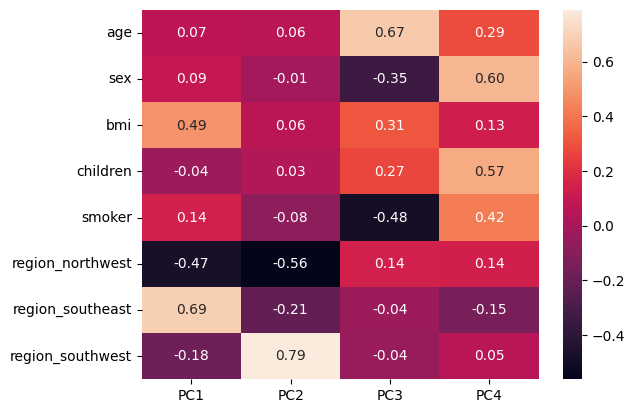

In [27]:
sns.heatmap(loadings_df, annot=True, fmt=".2f")

LETS COMPARE PCs BY VISUALIZING

When compare PC1 & PC2 we can clearly see 3 clusters in Purple color, Yellow color and Green color

Purple cluster has heighest PC2 values which mean mostly belongs to Southwest & Northwest Regions

Yellow cluster has Lower PC1 & PC2 values then Green cluster has Higher PC1 + Lower PC2 values

In [ ]:
#first plot comparing PC1 vs PC2, we can clearly see three distinct clusters — purple, yellow, and green. The purple cluster has the highest PC2 values, indicating that it mostly represents data points from the Southwest and Northwest regions. The yellow cluster shows lower PC1 and PC2 values, while the green cluster has higher PC1 but lower PC2 values, suggesting differences in feature combinations captured by these components. Overall, PC1 and PC2 effectively separate the dataset into three well-defined regional groups.

# Along with this plot comparing PC1 vs PC3, the clusters overlap more than in PC2, with yellow and purple concentrated at lower PC1 values and green dominating higher PC1 areas. PC3 introduces variation linked to age (0.67) and smoker (-0.48), highlighting demographic influence. While PC1 vs PC2 shows regional separation, PC1 vs PC3 captures behavioral and age-related differences among clusters.

#In the PC1 vs PC4 plot, three clusters—yellow, purple, and green—appear, with yellow and purple overlapping at lower PC1 values and green dominating higher PC1 areas. PC4 reflects variations related to sex (0.60) and children (0.57), showing demographic influence.

# plot comparing PC2 vs PC3, the clusters are distinctly separated along the PC2 axis, with purple having the highest PC2 values around 2.0, green centered near 0, and yellow around -1.5. This strong linear separation indicates that PC2 effectively differentiates the clusters. PC3, correlated with age (0.67) and smoker (-0.48), adds depth by revealing variation in age and smoking habits within each cluster.

In [ ]:
# plot comparing PC2 vs PC3, the clusters are distinctly separated along the PC2 axis, with purple having the highest PC2 values around 2.0, green centered near 0, and yellow around -1.5. This strong linear separation indicates that PC2 effectively differentiates the clusters. PC3, correlated with age (0.67) and smoker (-0.48), adds depth by revealing variation in age and smoking habits within each cluster.

# “PC2 vs PC4,” shows three distinct clusters of data points along the PC2 axis, indicating clear separation between groups based on their PC2 and PC4 values.

#T “PC3 vs PC4,” displays overlapping clusters with less distinct boundaries, suggesting that PC3 and PC4 do not separate the data as effectively as PC2 and PC4.

# PC2 vs PC4 is the best and more informative one because it clearly shows three well-separated clusters along the PC2 axis, indicating stronger differentiation between groups. In contrast, the PC3 vs PC4 shows significant overlap, meaning it provides weaker separation of clusters.

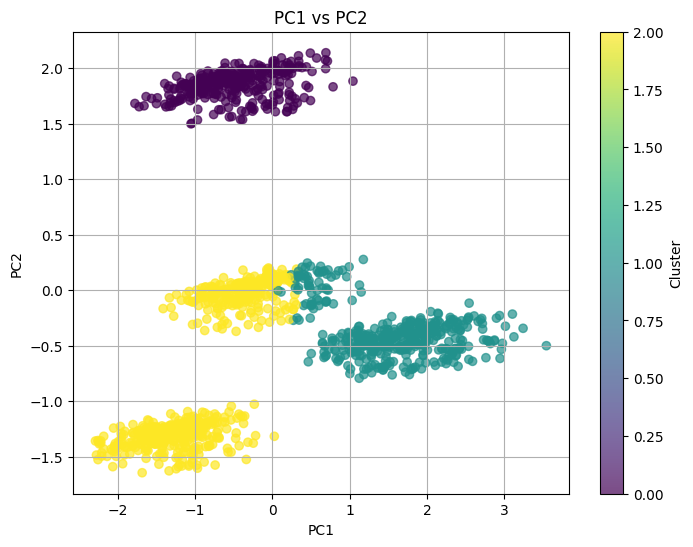

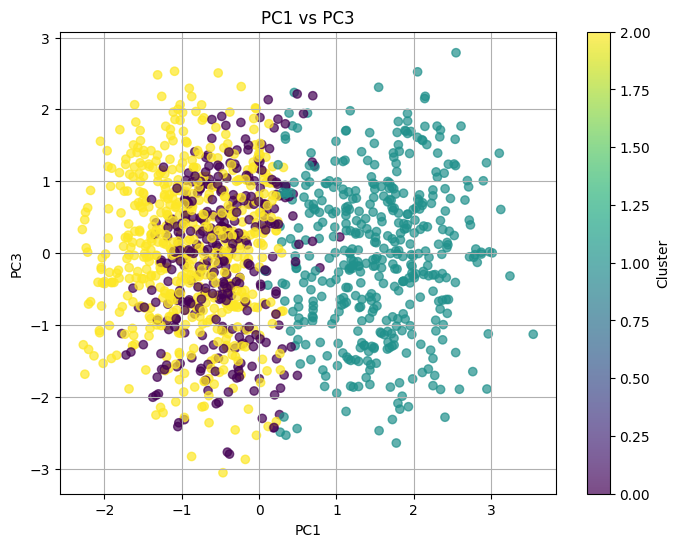

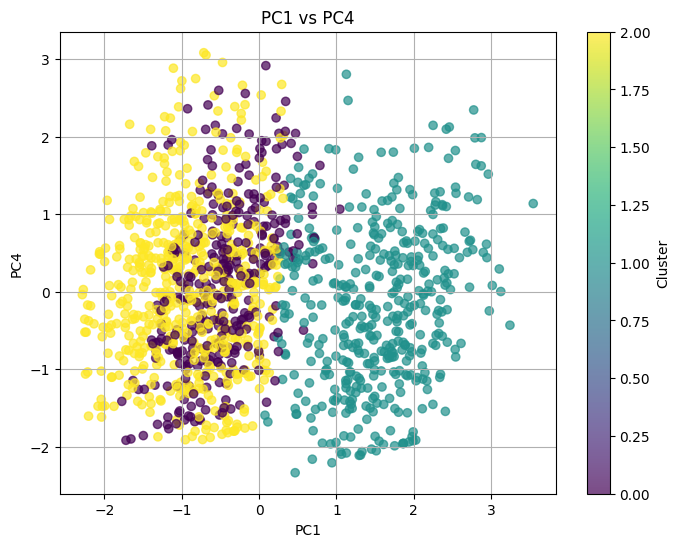

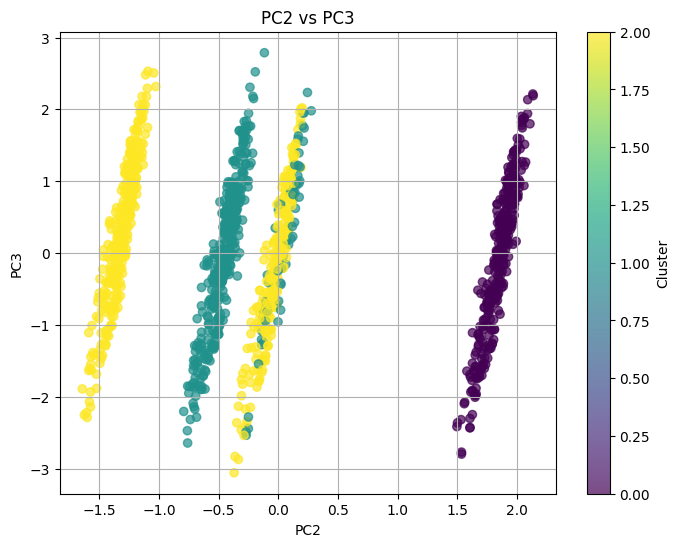

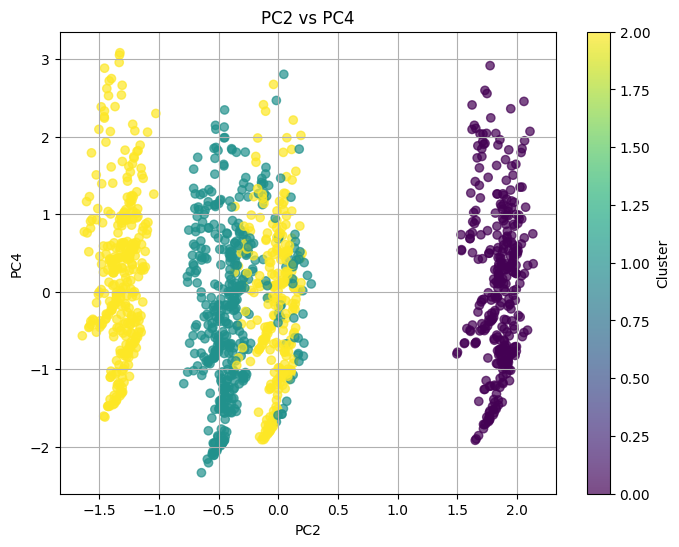

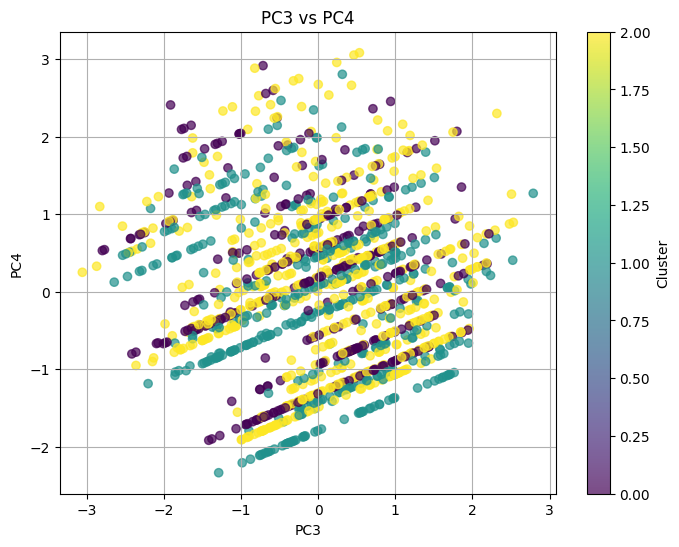

In [28]:
# helper function to compare and visualize PC-variables


def plot_pca_pairs(pca_result, components):
    num_c = pca_result.shape[1]

    # process each pair of PC-variables
    for i in range(num_c):
        for j in range(i + 1, num_c):
            plt.figure(figsize=(8, 6))
            plt.scatter(pca_result[:, i], pca_result[:, j], alpha=0.7)
            plt.title(f"PC{i+1} vs PC{j+1}")
            plt.xlabel(f"PC{i+1}")
            plt.ylabel(f"PC{j+1}")
            plt.grid(True)
            plt.show()


def plot_pca_pairs_with_clustering(pca_result, components, n_clusters=3):
    num_c = pca_result.shape[1]
    
    # Apply KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(pca_result)
    
    # Process each pair of PC-variables and plot clusters
    for i in range(num_c):
        for j in range(i + 1, num_c):
            plt.figure(figsize=(8, 6))
            scatter = plt.scatter(pca_result[:, i], pca_result[:, j], c=cluster_labels, cmap='viridis', alpha=0.7)
            plt.title(f"PC{i+1} vs PC{j+1}")
            plt.xlabel(f"PC{i+1}")
            plt.ylabel(f"PC{j+1}")
            plt.grid(True)
            plt.colorbar(scatter, label='Cluster')
            plt.show()

# plot_pca_pairs(X_pca, pca.components_)
# we can also use KMeans to visualize how well the data can be differentiated
# 3 is a good number to begin with for clusters, try also 6 (amount of options in the target)
plot_pca_pairs_with_clustering(X_pca, pca.components_, n_clusters=3)